In [1]:
import os
for item in os.listdir("CARLA"):
    print(item)

Data
model
roicropped
testing_data


In [2]:
print("Data folder:")
for item in os.listdir("CARLA/Data")[:20]:
    print(item)

Data folder:
Images
SteerValues


In [3]:
ff=os.listdir("CARLA/Data")[0]
print("First folder:",ff)
print(os.listdir(f"CARLA/Data/{ff}")[:20])

First folder: Images
['image000000000.png', 'image000000001.png', 'image000000002.png', 'image000000003.png', 'image000000004.png', 'image000000005.png', 'image000000006.png', 'image000000007.png', 'image000000008.png', 'image000000009.png', 'image000000010.png', 'image000000011.png', 'image000000012.png', 'image000000013.png', 'image000000014.png', 'image000000015.png', 'image000000016.png', 'image000000017.png', 'image000000018.png', 'image000000019.png']


In [4]:
print(os.listdir("CARLA/Data/SteerValues")[:20])

['steer_values.txt']


In [5]:
with open("CARLA/Data/SteerValues/steer_values.txt", "r") as fuu:
    for i in range(10):
        print(fuu.readline().strip())

-3.080117050558328629e-03
-3.916697110980749130e-03
-2.310646697878837585e-03
1.623472664505243301e-03
4.178800620138645172e-03
6.573832593858242035e-03
2.038893103599548340e-02
5.266948044300079346e-02
9.845584630966186523e-02
1.570324301719665527e-01


In [6]:
import os
num_images=len(os.listdir("CARLA/Data/Images"))
with open("CARLA/Data/SteerValues/steer_values.txt") as fu:
    steerVal=fu.readlines()
print("Images:",num_images)
print("steering values:",len(steerVal))

Images: 86491
steering values: 86491


In [7]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import torch
transform=transforms.Compose([
    transforms.Resize((66,200)),transforms.ToTensor()]) # PilotNet input size
class CarlaDataset(Dataset):
    def __init__(self,image_dir,steer_file, transform=None):
        self.image_dir=image_dir
        self.transform=transform
        self.images=sorted(os.listdir(image_dir))
        with open(steer_file,"r") as fuu:
            self.steerVal=[float(line.strip())
                           for line in fuu]
    def __len__(self):
        return len(self.images)
    def __getitem__(self,index):
        image_path=os.path.join(self.image_dir,self.images[index])
        image=Image.open(image_path).convert("RGB")
        if self.transform:
            image=self.transform(image)
        steering=torch.tensor(self.steerVal[index], dtype=torch.float32)
        return image,steering

In [8]:
dataset = CarlaDataset(
    image_dir="CARLA/Data/Images",
    steer_file="CARLA/Data/SteerValues/steer_values.txt",
    transform=transform)
print("dataset size:",len(dataset))

dataset size: 86491


In [9]:
image, steering=dataset[0]
print("Image shape:",image.shape)
print("Steering value:",steering)

Image shape: torch.Size([3, 66, 200])
Steering value: tensor(-0.0031)


In [10]:
from torch.utils.data import random_split
trainsize=int(0.8*len(dataset))
valsize=len(dataset)-trainsize
traindataset,valdataset = random_split(
    dataset,[trainsize,valsize])
print("Trainsample:",len(traindataset))
print("Validation samples:",len(valdataset))

Trainsample: 69192
Validation samples: 17299


In [11]:
from torch.utils.data import DataLoader
batch_size=64
train_loader=DataLoader( traindataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader( valdataset,batch_size=batch_size,shuffle=False)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 1082
Validation batches: 271


In [12]:
images, steering = next(iter(train_loader))

print("Images shape:", images.shape)
print("Steering shape:", steering.shape)

Images shape: torch.Size([64, 3, 66, 200])
Steering shape: torch.Size([64])


In [13]:
import torch.nn as nn
class PilotNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,24,kernel_size=5,stride=2),
            nn.ReLU(),
            nn.Conv2d(24,36,kernel_size=5,stride=2),
            nn.ReLU(),
            nn.Conv2d(36,48,kernel_size=5,stride=2),
            nn.ReLU(),
            nn.Conv2d(48,64,kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64,64,kernel_size=3),
            nn.ReLU()
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(1152, 100),
            nn.ReLU(),
            nn.Linear(100,50),
            nn.ReLU(),
            nn.Linear(50,10),
            nn.ReLU(),
            nn.Linear(10,1),
        )
    def forward(self,x):
        x=self.features(x)
        x=self.classifier(x)
        return x

In [14]:
model=PilotNet()
print(model)

PilotNet(
  (features): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=50, bias=True)
    (4): ReLU()
    (5): Linear(in_features=50, out_features=10, bias=True)
    (6): ReLU()
    (7): Linear(in_features=10, out_features=1, bias=True)
  )
)


In [15]:
outputs=model(images)
print("Output shape:", outputs.shape)

Output shape: torch.Size([64, 1])


In [16]:
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device ", device)

device  cpu


In [17]:
model= PilotNet().to(device)

In [19]:
import torch.optim as optm
criterion= nn.MSELoss()
optimizer=optm.Adam( model.parameters(),lr=0.001)


In [20]:
num_epochs=3
trainlosses=[]
vallosses=[]
for epoch in range(num_epochs):
    #Training starts
    model.train()
    running_loss=0
    for images,steering in train_loader:
        images=images.to(device)
        steering=steering.to(device)
        steering =steering.unsqueeze(1)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,steering)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    trainloss= running_loss / len(train_loader)
    trainlosses.append(trainloss)
    model.eval()
    valloss=0
    with torch.no_grad():
        for images,steering in val_loader:
            images=images.to(device)
            steering =steering.to(device)
            steering =steering.unsqueeze(1)
            outputs=model(images)
            loss=criterion(outputs, steering)
            valloss+=loss.item()
    valloss /=len(val_loader)
    vallosses.append(valloss)
    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {trainloss:.6f} | "
        f"Val Loss: {valloss:.6f}"
    )   
        

Epoch 1/3 | Train Loss: 0.006129 | Val Loss: 0.004028
Epoch 2/3 | Train Loss: 0.003060 | Val Loss: 0.002463
Epoch 3/3 | Train Loss: 0.002105 | Val Loss: 0.001881


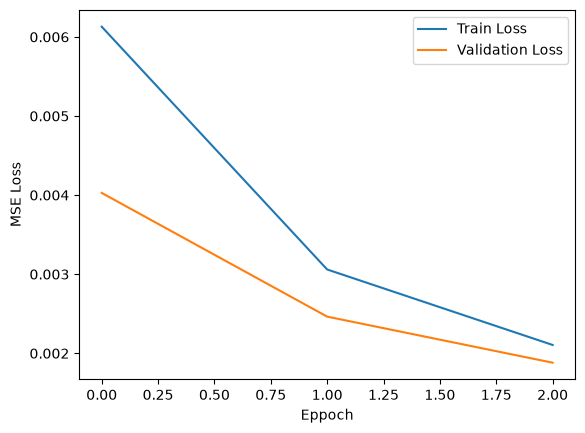

In [21]:
import matplotlib.pyplot as plt
plt.plot(trainlosses, label="Train Loss")
plt.plot(vallosses, label="Validation Loss")
plt.xlabel("Eppoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [22]:
images,steering= next(iter(val_loader))
images=images.to(device)
model.eval()
with torch.no_grad():
    preds=model(images)
for a in range(5):
    print(f"True: {steering[a].item():.4f} "
          f"Pred: {preds[a].cpu().item():.4f}")


True: 0.0039 Pred: -0.0050
True: 0.0005 Pred: 0.0065
True: 0.0027 Pred: -0.0013
True: -0.0022 Pred: 0.0020
True: 0.0003 Pred: 0.0075


In [24]:
torch.save(model.state_dict(), "pilotnet_task1.pth")


In [25]:
images, steering= next(iter(val_loader))
images=images.to(device)
model.eval()
with torch.no_grad():
    preds = model(images)

for i in range(10):
    print(
        f"True: {steering[i].item():.4f} | "
        f"Pred: {preds[i].cpu().item():.4f}"
    )

True: 0.0039 | Pred: -0.0050
True: 0.0005 | Pred: 0.0065
True: 0.0027 | Pred: -0.0013
True: -0.0022 | Pred: 0.0020
True: 0.0003 | Pred: 0.0075
True: 0.0128 | Pred: 0.0033
True: -0.0008 | Pred: 0.0050
True: 0.0032 | Pred: 0.0195
True: -0.0132 | Pred: 0.0025
True: 0.0011 | Pred: 0.1014


In [27]:
import torch
model.eval()
mae=0
c=0
with torch.no_grad():
    for images,steering in val_loader:
        images=images.to(device)
        steering=steering.to(device).unsqueeze(1)
        preds=model(images)
        mae+=torch.abs(preds - steering).sum().item()
        c+= steering.numel()
mae/=c
print("validation MAE is",mae)

validation MAE is 0.02084894167962767
